In [1]:
# Import necessary packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

In [2]:
# Load in confidence file, look at pipeline to see how this was generated
emp = pd.read_csv('data/TP53_emp.csv')

In [3]:
# Extract rank values and normalized confidence values from the empirical results table
x = emp['index'].values
y = emp['norm_confidence'].values

# Use the first observed point as an anchor for the fitted curve
x0, y0 = x[0], y[0]

# Define a logistic function constrained to pass through the first point, (x0, y0)
def logistic_fixed_first(x, k, xmid, c):
    # Calculate L so the logistic curve passes exactly through (x0, y0)
    L = (y0 - c) * (1 + np.exp(k * (x0 - xmid)))
    
    # Return the logistic curve values
    return c + L / (1 + np.exp(k * (x - xmid)))

# Set initial guesses for the curve-fitting parameters:
# k controls curve steepness, xmid is the midpoint, and c is the lower asymptote
p0 = [-0.05, np.median(x), min(y)]

# Fit the constrained logistic curve to the observed data
popt, _ = curve_fit(logistic_fixed_first, x, y, p0=p0, maxfev=10000)

# Unpack the fitted parameters
k, xmid, c = popt

# Generate fitted y-values using the optimized logistic parameters
y_pred = logistic_fixed_first(x, *popt)

# Calculate R² to measure how well the fitted curve explains the observed data
r2 = r2_score(y, y_pred)

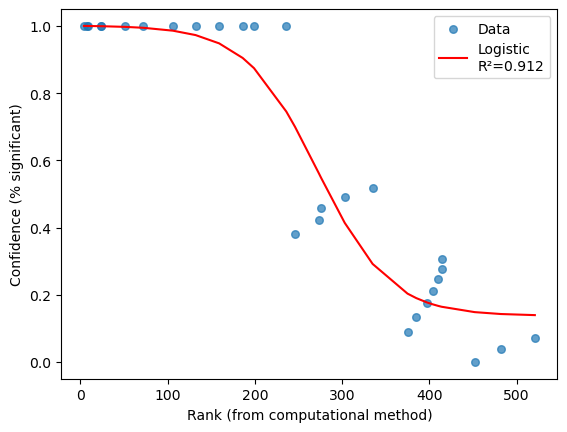

In [4]:
# Plot the observed data points
plt.scatter(x, y, s=30, alpha=0.7, label='Data')

# Plot the fitted logistic curve over sorted x-values so the line is smooth
plt.plot(
    np.sort(x),
    logistic_fixed_first(np.sort(x), *popt),
    color='red',
    label=f'Logistic\nR²={r2:.3f}'
)

# Label axes and display the plot
plt.xlabel('Rank (from computational method)')
plt.ylabel('Confidence (% significant)')
plt.legend()
plt.grid(False)
plt.show()